# Readme

Plot all functional and retina edge recordings.
Connect the edge recordings to show the outline of the Retina.
Note that the first edge recording is actually the optic disc.

In [1]:
import os

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
data_folder = "../../data/preprocessed-data"

df_rois = pd.concat([pd.read_hdf(os.path.join(data_folder, f'df_eyewire2_roi_level_GCL{i}.h5'), key='dataframe') for i in range(5)])
df_fields = pd.read_hdf(os.path.join(data_folder, 'df_eyewire2_field_level.h5'), key='dataframe')
df_outline = pd.read_hdf(os.path.join(data_folder, 'df_eyewire2_outline.h5'), key='dataframe')

In [3]:
def plot_stack_average(ax, stack_avg, pixel_size_um, x_offset, y_offset, cmap='viridis', alpha=0.7, gamma=0.5):
    ps = pixel_size_um
    w, h = stack_avg.shape[:2]
    assert w == h
    extent = np.array([-w / 2 * ps, +w / 2 * ps, -w / 2 * ps, +w / 2 * ps])
    extent += (x_offset, x_offset, y_offset, y_offset)

    im = stack_avg.astype(float)
    vmin = np.percentile(im, q=5, axis=(0, 1))
    vmax = np.percentile(im, q=99, axis=(0, 1))
    im = (im - vmin) / (vmax - vmin)
    im = np.clip(im, 0, 1) ** gamma

    ax.imshow(im.T, extent=extent, cmap=cmap, interpolation='none', alpha=alpha)

In [4]:
fig_dir = './figures/retinal_locations'
os.makedirs(fig_dir, exist_ok=True)

In [5]:
def plot_retina_orientation(ax, tdist=50, x0=0, y0=0, size=1000):
    ax.plot([x0 - size / 2, x0 + size / 2], [y0, y0], c='k', dash_capstyle='butt', clip_on=False)
    ax.plot([x0, x0], [y0 - size / 2, y0 + size / 2], c='k', dash_capstyle='butt', clip_on=False)
    ax.text(x0 - size / 2 - tdist, y0, 'N', c='k', va='center', ha='right')
    ax.text(x0 + size / 2 + tdist, y0, 'T', c='k', va='center', ha='left')
    ax.text(x0, y0 - size / 2 - tdist, 'V', c='k', va='top', ha='center')
    ax.text(x0, y0 + size / 2 + tdist, 'D', c='k', va='bottom', ha='center')


def plot_scale_bar(ax, x0=0, y0=0, size=1000, tdist=70):
    ax.plot([-size / 2 + x0, +size / 2 + x0], [y0, y0], c='k', dash_capstyle='butt', clip_on=False)
    ax.text(x0, y0 - tdist, f'{size / 1000:.0f} mm', c='k', va='top', ha='center')

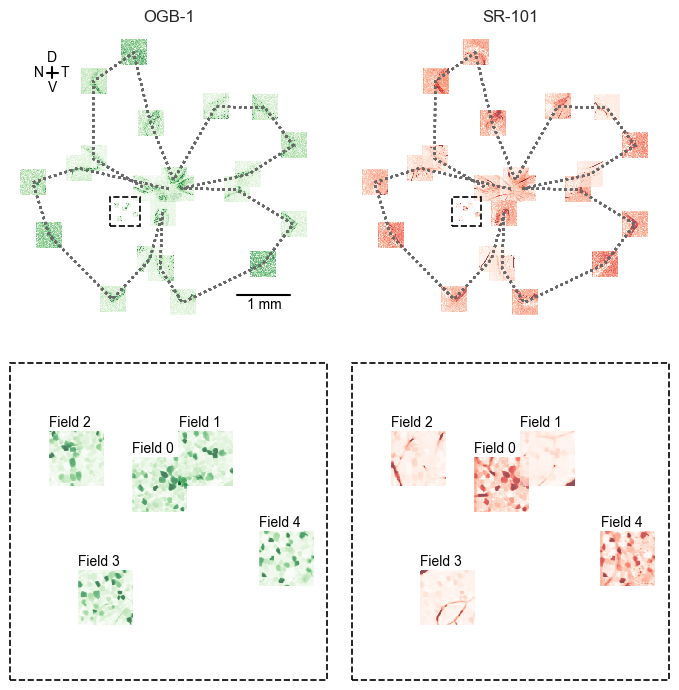

In [6]:
cmaps = ['Greens', 'Reds']
color_crop = 'k'

fig, axs_all = plt.subplots(2, 2, figsize=(7, 7), sharey='row', sharex='row')

axs = axs_all[0, :]
for i, row in df_outline.iterrows():
    for j, ax in enumerate(axs):
        plot_stack_average(
            ax, row['stack_averages'][:, :, j],
            row['pixel_size_um'],
            row['temporal_nasal_pos_um'], row['ventral_dorsal_pos_um'],
            cmap=cmaps[j])

    for ax in axs:
        ax.set(xlim=(-3000, 3000), ylim=(-3000, 3000))
        #ax.set(xlabel='Temporal <-> Nasal [um]', ylabel='Ventral <-> Dorsal [um]')
        ax.plot(df_outline['temporal_nasal_pos_um'],
                df_outline['ventral_dorsal_pos_um'], c='dimgray', ls=':')
        ax.axis('off')
        #ax.grid()
        ax.set_aspect('equal')

for axs in axs_all:
    for i, row in df_fields.iterrows():
        for j in [0, 1]:
            if axs[j] in axs_all[1, :]:
                axs[j].text(row['field_temporal_nasal_pos_um'] - 10, row['field_ventral_dorsal_pos_um'] + 50,
                            'Field ' + row.field[-1], c='k', va='bottom', ha='center')
            plot_stack_average(
                axs[j], row[f'ch{j}_average'],
                row['pixel_size_um'],
                row['field_temporal_nasal_pos_um'], row['field_ventral_dorsal_pos_um'],
                cmap=cmaps[j])
box_xlim = (-1100, -550)
box_ylim = (-700, -150)
for ax in axs_all[1, :]:
    ax.set(xlim=box_xlim, ylim=box_ylim)
    #ax.set(xlabel='Retinal location [µm]\nTemporal ↔ Nasal', ylabel='Position [µm]\nVentral ↔ Dorsal')
    ax.axis('off')
    #ax.grid()
    ax.set_aspect('equal')

for ax in axs_all.flat:
    rect = patches.Rectangle(
        (box_xlim[0], box_ylim[0]), box_xlim[1] - box_xlim[0], box_ylim[1] - box_ylim[0],
        linewidth=1.2, edgecolor=color_crop, facecolor='none', linestyle='--', clip_on=False
    )
    ax.add_patch(rect)

plot_retina_orientation(ax=axs_all[0, 0], tdist=50, x0=-2200, y0=2200, size=200)
plot_scale_bar(ax=axs_all[0, 0], x0=1800, y0=-2000, size=1000, tdist=70)

axs_all[0, 0].set_title('OGB-1')
axs_all[0, 1].set_title('SR-101')

plt.savefig(os.path.join(fig_dir, 'erm_retinal_field_locations.pdf'))
plt.tight_layout()
plt.show()

# Plot function

In [7]:
def plot_mean_and_sd(ax, traces, time, color='black', alt_color='dimgray', facealpha=0.2, offset=0.0):
    if traces.shape[0] <= 2:
        ax.plot(time, traces[0] - np.mean(traces[0]) + offset, color=color)
        if len(traces) == 2:
            ax.plot(time, traces[1] - np.mean(traces[1]) + offset, color=alt_color)
    else:
        mu = np.mean(traces, axis=0)
        mu = mu - np.mean(mu) + offset
        sd = np.std(traces, axis=0)

        ax.plot(time, mu, color=color)
        ax.fill_between(time, mu - sd, mu + sd, color=color, alpha=facealpha)

In [8]:
swc_dir = 'Y:/data/Eyewire2/morphologies-ew2/swc-norm/c6fb66deed2b53502e41fdcec0caa3b9'
swc_files = [f for f in os.listdir(swc_dir) if f.endswith('.swc')]

In [9]:
morph_folder = "../../data/morphological-data"
morph_spreadsheet_filename = "Eyewire II Proofread Cells Master List - All Cells 2025-09-09.csv"

df_master = pd.read_csv(os.path.join(os.path.join(morph_folder, morph_spreadsheet_filename)), dtype=str)

nuc_col_master = 'Updated Nuc ID (Sept 2)'
seg_col_master = 'Updated Seg ID (Sept 2)'
assert seg_col_master in df_master.columns, f"Column '{seg_col_master}' not found in df_master"
assert nuc_col_master in df_master.columns, f"Column '{nuc_col_master}' not found in df_master"

print(df_master.shape)
df_master.head()

(8687, 35)


,Index,Nuc Coords,Soma Coords,Cell Type (deprecated),611 Proofreader,Proofreader 2,Status,AIS annotated?,Final Link,Final NucID,...,Machine soma location,Additional Notes,Index OK?,Index for sanity check,Updated Nuc ID (Sept 2),Updated Seg ID (Sept 2),Cell Requires Review (DO NOT use Updated IDs for those cells),Review complete,Review notes,Cutoff Severity for Status=Complete (cut off) cells (%Hits Edge & Can't Fix Annotations in Proofreading link)
0,A4,NaN,NaN,OFF-SAC,Roden Rey,NaN,Complete (cut off),NaN,https://spelunker.cave-explorer.org/#!middleau...,NaN,...,INL,NaN,ok,A4,NaN,NaN,FALSE,NaN,NaN,NaN
1,A5,NaN,NaN,OFF-SAC,Christine,NaN,Complete (cut off),NaN,https://spelunker.cave-explorer.org/#!middleau...,NaN,...,INL,NaN,ok,A5,NaN,NaN,FALSE,NaN,NaN,NaN
2,A7,"63573, 49070, 1720","63537, 49048, 1697",OFF-SAC,April Grace,NaN,Complete,NaN,https://spelunker.cave-explorer.org/#!middleau...,720575940545056597,...,INL,NaN,ok,A7,720575940545056597,720575940572159335,FALSE,NaN,NaN,NaN
3,A11,"50561, 64354, 1734","50520, 64370, 1656",OFF-SAC,Roden Rey,NaN,Complete,NaN,https://spelunker.cave-explorer.org/#!middleau...,720575940544186175,...,INL,NaN,ok,A11,720575940544186175,720575940563309953,FALSE,NaN,NaN,NaN
4,A12,NaN,NaN,OFF-SAC,Roden Rey,NaN,Complete (cut off),NaN,https://spelunker.cave-explorer.org/#!middleau...,NaN,...,INL,NaN,ok,A12,NaN,NaN,FALSE,NaN,NaN,NaN


In [10]:
df_merged = pd.merge(
    df_master.set_index(nuc_col_master),
    df_rois.set_index(df_rois['nuc_id'].astype(str)),
    left_index=True, right_index=True, how='inner'
).reset_index()

print(df_merged.shape)
df_merged.head()

(379, 105)


,Updated Nuc ID (Sept 2),Index,Nuc Coords,Soma Coords,Cell Type (deprecated),611 Proofreader,Proofreader 2,Status,AIS annotated?,Final Link,...,cluster_id,group_id,supergroup,prob_cluster,prob_group,prob_supergroup,prob_class,probs_per_cluster,seg_id,nuc_id
0,720575940577751704,D1,"32653.0,23923.0,553.0","32653.0,23923.0,583.0",NaN,Elison,Greg,Complete,Annotated,https://spelunker.cave-explorer.org/#!middleau...,...,18,12,ON-OFF,0.804667,0.819760,0.832646,0.913740,"[0.0020822615335256726, 0.0032838992937911002,...",720575940550529705,720575940577751704
1,720575940534317101,D2,"33159.0,22959.0,606.0","33159.0,22959.0,661.0",NaN,Juliane,Jonathan,Complete,Annotated,https://spelunker.cave-explorer.org/#!middleau...,...,51,34,dAC,0.605752,0.615440,0.702638,0.702638,"[0.003336756586838654, 0.008818983121221289, 0...",720575940568652126,720575940534317101
2,720575940554891618,D3,"33787.0,21853.0,597.0","33787.0,21853.0,677.0",ON-SAC,Nseraf,Juliane,Complete,AC,https://spelunker.cave-explorer.org/#!middleau...,...,68,42,dAC,0.772927,0.790771,0.927322,0.927322,"[0.0017071109567420337, 0.0016375104799094017,...",720575940572885792,720575940554891618
3,720575940554657378,D4,"34131.0,21306.0,627.0","34131.0,21306.0,657.0",NaN,Christine,NaN,Complete,AC,https://spelunker.cave-explorer.org/#!middleau...,...,74,46,dAC,0.488712,0.494132,0.803859,0.803859,"[0.0028589256378742686, 0.003341772704406851, ...",720575940566222700,720575940554657378
4,720575940571117757,D5,"34753.0,20187.0,669.0","34753.0,20187.0,684.0",NaN,Glenda,Greg,Complete,NaN,https://spelunker.cave-explorer.org/#!middleau...,...,38,28,Slow ON,0.580714,0.581366,0.590559,0.629739,"[0.0012246466912174362, 0.0011384551512382875,...",720575940577371948,720575940571117757


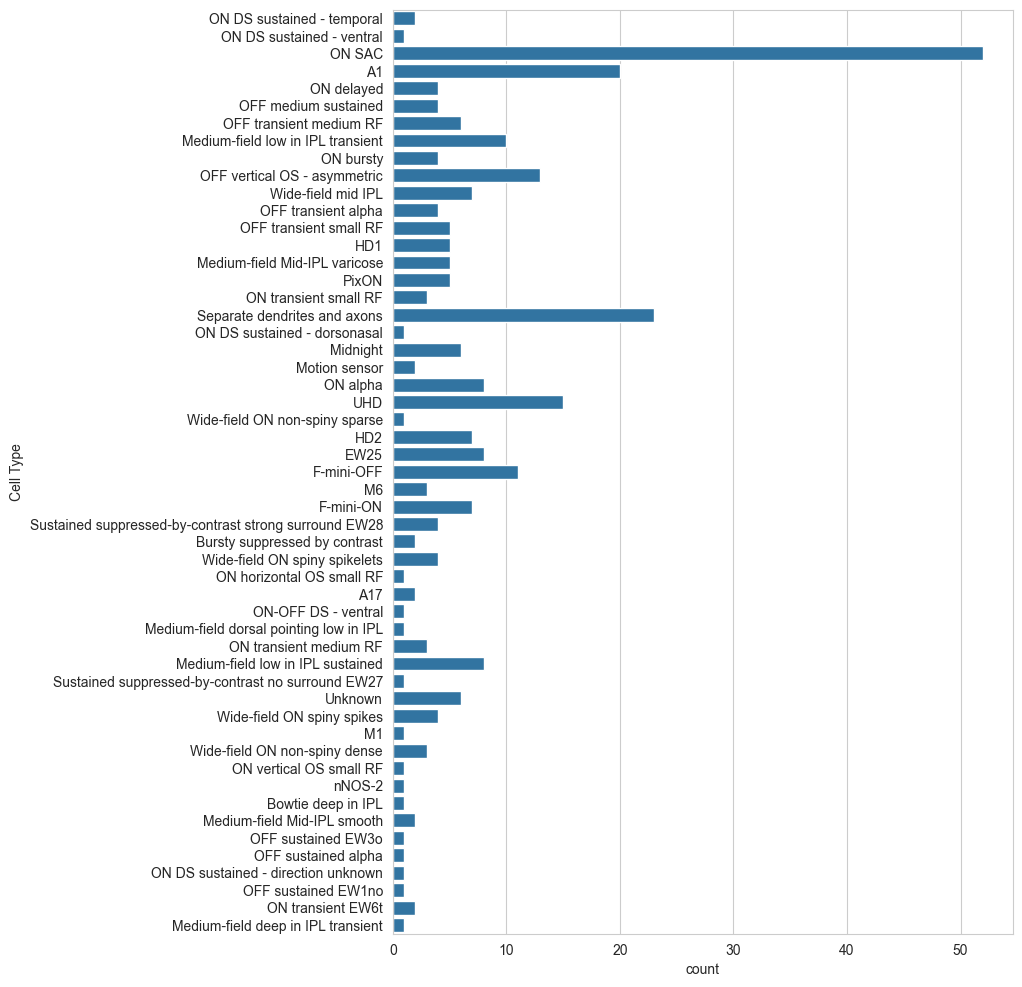

In [11]:
import seaborn as sns

fig, ax = plt.subplots(1, 1, figsize=(8, 12))
sns.countplot(ax=ax, data=df_merged, y='Cell Type')
plt.show()

In [12]:
# DSI / OSI from djimaging

MB_DIRS = (0, 180, 45, 225, 90, 270, 135, 315)


def get_dir_idx(snippets, dir_order=MB_DIRS):
    """
    snippets: np.ndarray (times, dirs*reps)
    dir_order: np.ndarray (dirs, ) or (dirs*reps, )
    """
    dir_order = np.asarray(dir_order).squeeze()
    assert dir_order.ndim == 1, dir_order.shape
    assert snippets.ndim == 2, snippets.shape
    n_snippets = snippets.shape[-1]
    assert (n_snippets % dir_order.size) == 0, f"Snippet length {n_snippets} is not a multiple of {dir_order.size}"
    dir_order = np.tile(dir_order, n_snippets // dir_order.size)
    assert n_snippets == dir_order.size

    dir_deg = dir_order[:8]  # get the directions of the bars in degree
    dir_rad = np.deg2rad(dir_deg)  # convert to radians
    dir_idx = [list(np.where(dir_order == d)[0]) for d in dir_deg]

    return dir_idx, dir_rad


def sort_response_matrix(snippets: np.ndarray, idxs: list, directions: np.ndarray):
    """
    Sorts the snippets according to stimulus condition and repetition into a time x direction x repetition matrix
    Inputs:
    snippets    list or array, time x (directions*repetitions)
    idxs        list of lists giving idxs into last axis of snippets. idxs[0] gives the indexes of rows in snippets
                which are responses to the direction directions[0]
    Outputs:
    sorted_responses   array, time x direction x repetitions, with directions sorted(!) (0, 45, 90, ..., 315) degrees
    sorted_directions   array, sorted directions
    """
    structured_responses = snippets[:, idxs]
    sorting = np.argsort(directions)
    sorted_responses = structured_responses[:, sorting, :]
    sorted_directions = directions[sorting]
    return sorted_responses, sorted_directions


def preprocess_mb_snippets(snippets, dir_order=MB_DIRS):
    dir_idx, dir_rad = get_dir_idx(snippets, dir_order)

    sorted_responses, sorted_directions = sort_response_matrix(snippets, dir_idx, dir_rad)
    sorted_averages = np.mean(sorted_responses, axis=-1)
    return sorted_directions, sorted_responses, sorted_averages


def get_time_dir_kernels(sorted_responses: np.ndarray, dt: float):
    """
    Performs singular value decomposition on the time x direction matrix (averaged across repetitions)
    Uses a heuristic to try to determine whether a sign flip occurred during svd
    For the time course, the mean of the first second is subtracted and then the vector is divided by the maximum
    absolute value.
    For the direction/orientation tuning curve, the vector is normalized to the range (0,1)

    Parameters:
    sorted_responses (array): Time x direction matrix.
    dt (float): 1 / sampling_rate of trace.

    Returns:
    tuple: Contains time_kernel (array, time x 1), direction_tuning (array, directions x 1), and singular_value (float).
    """
    U, S, Vh = np.linalg.svd(sorted_responses)

    time_component = U[:, 0]
    dir_component = Vh[0, :]

    # the time_kernel determined by SVD should be correlated to the average response across all directions. if the
    # correlation is negative, U is likely flipped

    if np.mean((-1 * time_component - np.mean(sorted_responses, axis=-1)) ** 2) < np.mean(
            (time_component - np.mean(sorted_responses, axis=-1)) ** 2
    ):
        su = -1
    else:
        su = 1

    sv = np.sign(np.mean(np.sign(dir_component)))
    if sv == 1 and su == 1:
        s = 1
    elif sv == -1 and su == -1:
        s = -1
    elif sv == 1 and su == -1:
        s = 1
    elif sv == 0:
        s = su
    else:
        s = 1

    time_component *= s
    dir_component *= s

    # determine which entries correspond to the first second, assuming 4 seconds presentation time
    first_second_idx = np.maximum(int(np.floor(1.0 / dt)), 1)
    time_component -= np.mean(time_component[:first_second_idx])
    time_component = time_component / np.max(np.abs(time_component))

    #dir_component -= np.min(dir_component)
    #dir_component = dir_component / np.max(dir_component)

    return time_component, dir_component

In [13]:
t_chirp = np.arange(df_merged.chirp_average_norm.iloc[0].size) * df_merged.chirp_average_dt.iloc[0]
t_bar = np.arange(df_merged.bar_time_component.iloc[0].size) * df_merged.bar_snippets_dt.iloc[0]

In [14]:
import skeliner as sk


def plot_chirp(ax, row):
    snippets = row['chirp_snippets']
    for i, trace in enumerate(snippets.T):
        ax.plot(np.arange(0, len(trace)) * row['chirp_snippets_dt'], trace / np.max(np.abs(trace)), color='dimgray',
                alpha=0.5)
    ax.plot(np.arange(0, len(row['chirp_average_norm'])) * row['chirp_average_dt'], row['chirp_average_norm'],
            color='darkred', alpha=0.8)
    #ax.axhline(0, c='dimgray', ls='--')
    #for t in [2, 5, 8, 30]:
    #   ax.axvline(t, c='dimgray', ls='--')


def plot_bar(ax, row, annotate_dirs=False):
    for i, dir in enumerate(MB_DIRS):
        snippets = row['bar_snippets'][:, np.array([0, 8, 16]) + i]
        time = (np.arange(0, snippets.shape[0]) + (snippets.shape[0] * 1.2 * i)) * row['bar_snippets_dt']
        for trace in snippets.T:
            ax.plot(time, trace, color='dimgray', alpha=0.5)
        ax.plot(time, np.mean(snippets, axis=1), color='darkred', alpha=0.8)
        ax.axhline(0, c='dimgray', ls='--')
        if annotate_dirs:
            ax.text(time[0] + 0.5 * (time[-1] - time[0]), np.max(row['bar_snippets']) + 0.1, f'{dir}°',
                    ha='center', va='top', fontsize=8)


def plot_bar_dir(ax, row):
    if np.any(~np.isfinite(row['bar_snippets'])):
        raise ValueError('bar_snippets not finite')

    sorted_directions, sorted_responses, sorted_averages = preprocess_mb_snippets(snippets=row['bar_snippets'])
    time_component, dir_component = get_time_dir_kernels(sorted_averages, dt=row['bar_snippets_dt'])
    sorted_directions = np.append(sorted_directions, sorted_directions[0])
    dir_component = np.append(dir_component, dir_component[0])

    if np.any(~np.isfinite(dir_component)):
        raise ValueError('dir_component not finite')

    ax.plot(sorted_directions, np.clip(dir_component, 0, None), color='darkred', alpha=0.8, lw=2)
    ax.xaxis.set_tick_params(pad=-20)


def plot_morph(ax, row):
    sk.plot.projection(row.skel, ax=ax, plane='xy')  #, color_by="ntype", skel_cmap='Grays')
    sx, sy, sz = row.skel.soma.center

    ax.set_xlim(sx - 200, sx + 200)

    ax.set_ylim(sy - 200, sy + 200)

In [15]:
def add_skels(df):
    df = df.copy()

    df['swc_path'] = df[seg_col_master].apply(lambda x: os.path.join(swc_dir, f"{x}.swc"))
    df['swc_exists'] = df['swc_path'].apply(lambda x: os.path.isfile(x))
    if np.any(~df['swc_exists']):
        print('SWC not found:', df[~df['swc_exists']].swc_path)
    df = df[df['swc_exists']]
    df['skel'] = df['swc_path'].apply(lambda x: sk.io.load_swc(x))
    return df

def plot_cells(df):
    assert df.shape[0] > 0, "No data to plot"
    df = add_skels(df)

    fig, axs = plt.subplots(len(df), 4, figsize=(8, len(df) * 1.2), width_ratios=(1, 2, 2, 1))

    for i, ax_to_replace in enumerate(axs[:, -1]):
        ax_to_replace.remove()
        polar_ax = fig.add_subplot(ax_to_replace.get_subplotspec(), polar=True)
        axs[i, -1] = polar_ax

    for i, (seg_id, row) in enumerate(df.iterrows()):
        plot_morph(ax=axs[i, 0], row=row)
        plot_chirp(ax=axs[i, 1], row=row)
        plot_bar(ax=axs[i, 2], row=row, annotate_dirs=i == 0)
        plot_bar_dir(ax=axs[i, 3], row=row)

    for ax in axs[:, :-1].flat:
        ax.set(xlabel=None, ylabel=None, xticks=[], yticks=[])
        ax.axis('off')

    for ax in axs[:, -1].flat:
        ax.set(xlabel=None, ylabel=None, xticks=np.deg2rad([0, 90, 180, 270]), yticks=[], ylim=(0, None))

    plt.tight_layout()
    return fig, axs

In [16]:
import cell_mosaics

def plot_mosaic(df, extent = (350, 1000, 0, 650)):
    assert df.shape[0] > 0, "No data to plot"
    df = add_skels(df)

    mapper = cell_mosaics.CoverageDensityMapper(field_bounds=extent, resolution=500)
    for i, (seg_id, row) in enumerate(df.iterrows()):
        mapper.add_convex_hull(row.skel.nodes[row.skel.nodes[:, 2] > -10, :2])
    fig, ax, im = mapper.plot_coverage(colormap='bone_r', plot_cell_outlines=True)
    for i, (seg_id, row) in enumerate(df.sample(1).iterrows()):
        plot_morph(ax=ax, row=row)
    ax.set(xlim=extent[:2], ylim=extent[2:])
    return fig, ax

In [17]:
fig2_dir = './figures/examples'
os.makedirs(fig2_dir, exist_ok=True)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


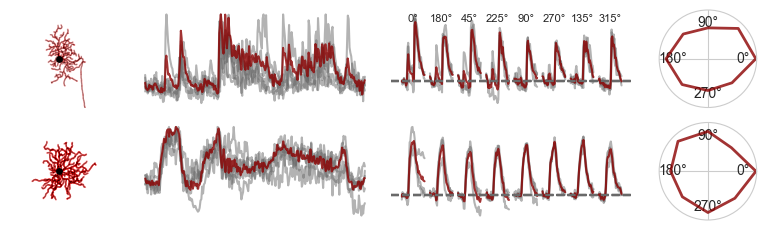

In [18]:
# For Sebastian
df_type = df_merged[
    (df_merged['roi_id'].astype(int).isin([62, 52]))
    & (df_merged["field"] == 'GCL2')
    ]
df_type = df_type.drop_duplicates(subset=[seg_col_master], keep='first')

fig, axs = plot_cells(df_type)
plt.savefig(os.path.join(fig2_dir, 'examples_GCL2_52_62.eps'))
plt.show()

[720575940563265819 720575940572551485 720575940576369093
 720575940562015742 720575940546061452 720575940583667923
 720575940551647474 720575940547919816 720575940576381125
 720575940561194713 720575940579488144 720575940560950763]


,Updated Seg ID (Sept 2),Cell Type,Machine label
45,720575940563265819,UHD,5ti
50,720575940572551485,UHD,5ti
54,720575940576369093,UHD,5ti
90,720575940562015742,UHD,5ti
96,720575940546061452,UHD,5ti
105,720575940583667923,UHD,5ti
151,720575940551647474,UHD,5ti
164,720575940547919816,UHD,5ti
168,720575940576381125,UHD,5ti
186,720575940561194713,UHD,5ti


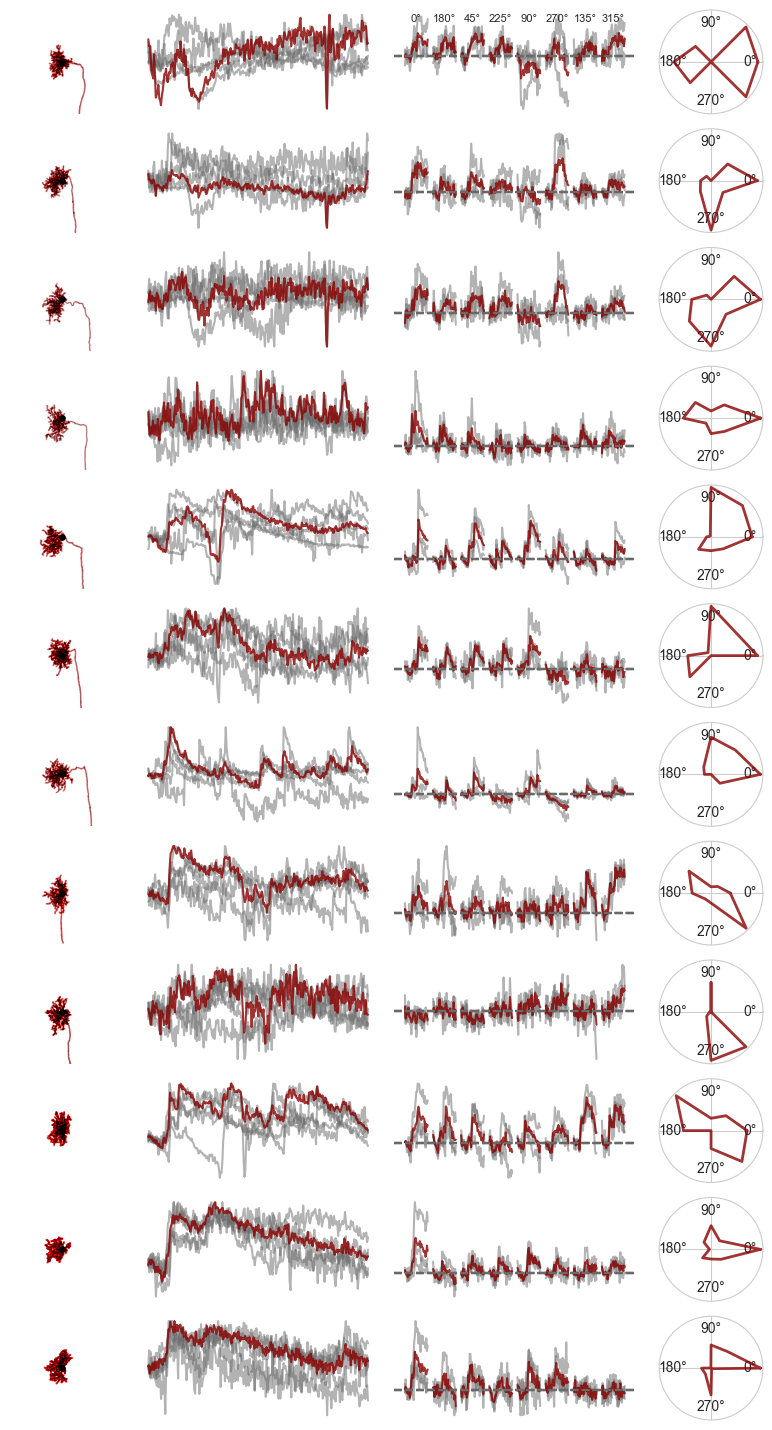

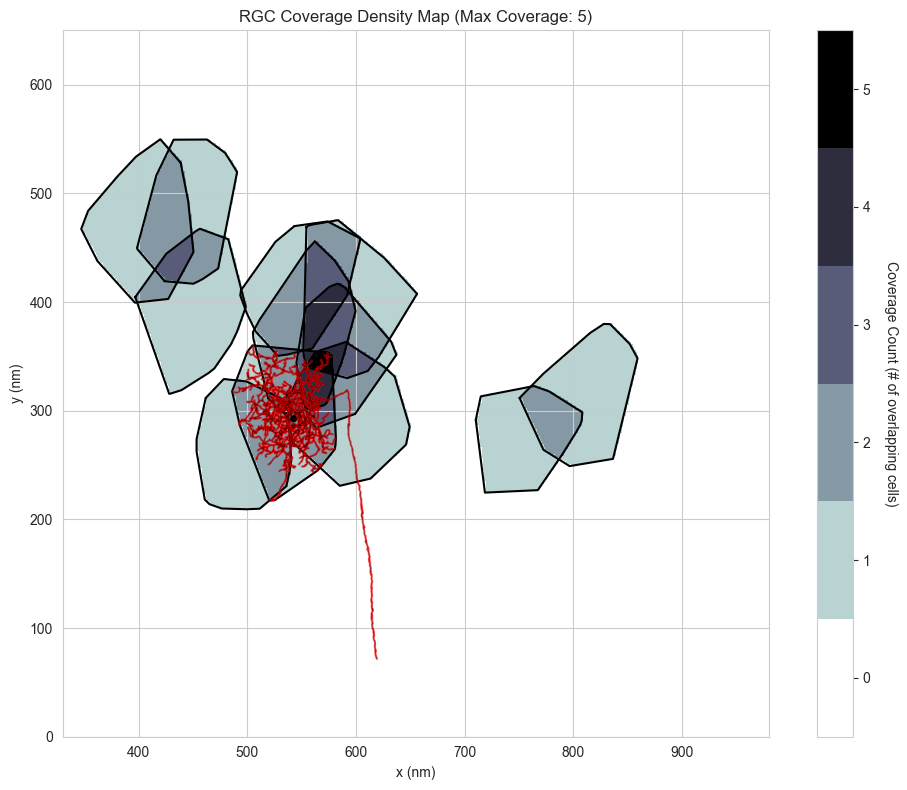

In [19]:
uhd_list = [720575940546061452, 720575940547919816, 720575940551647474, 720575940560950763, 720575940561194713,
            720575940562015742, 720575940563265819, 720575940572551485, 720575940576369093,
            720575940576381125, 720575940579488144, 720575940583667923]

df_type = df_merged[
    #((df_merged['Cell Type'] == 'UHD') | ((df_merged['Machine label'] == '5ti') & (df_merged['Confidence machine label'].astype(float) > 0.5)))
    (df_merged[seg_col_master].astype(int).isin(uhd_list))
    & ((df_merged.chirp_qidx > 0.45) | (df_merged.bar_qidx > 0.6))
    & (df_merged["Status"] == 'Complete')
    ]
df_type = df_type.drop_duplicates(subset=[seg_col_master], keep='first')

print(df_type[seg_col_master].values.astype(int))
display(df_type[[seg_col_master, 'Cell Type', 'Machine label']])

fig, axs = plot_cells(df_type)
plt.savefig(os.path.join(fig2_dir, 'examples_uhd.pdf'))
plt.show()

fig, ax = plot_mosaic(df_type, extent = (330, 980, 0, 650))
plt.savefig(os.path.join(fig2_dir, 'mosaic_uhd.pdf'))
plt.show()

[720575940563265819 720575940572551485 720575940576369093
 720575940562015742 720575940546061452 720575940583667923
 720575940551647474 720575940547919816 720575940576381125
 720575940561194713 720575940579488144 720575940560950763]


,Updated Seg ID (Sept 2),Cell Type,Machine label
45,720575940563265819,UHD,5ti
50,720575940572551485,UHD,5ti
54,720575940576369093,UHD,5ti
90,720575940562015742,UHD,5ti
96,720575940546061452,UHD,5ti
105,720575940583667923,UHD,5ti
151,720575940551647474,UHD,5ti
164,720575940547919816,UHD,5ti
168,720575940576381125,UHD,5ti
186,720575940561194713,UHD,5ti


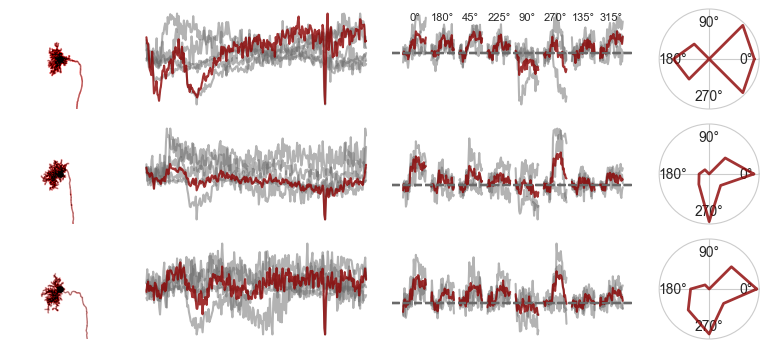

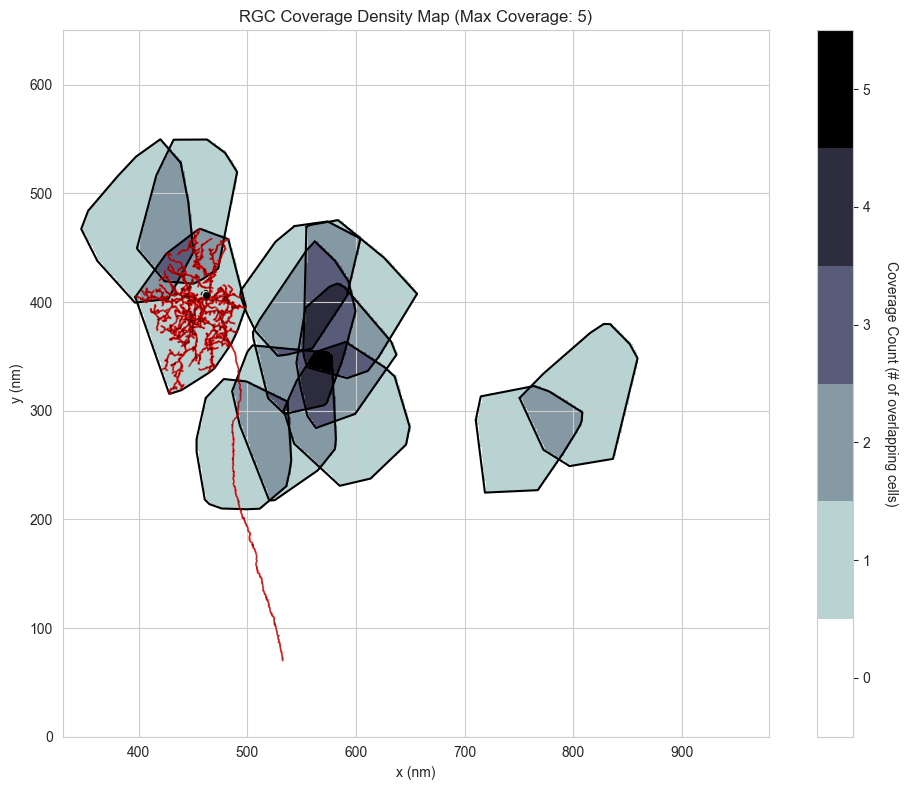

In [30]:
uhd_list = [720575940546061452, 720575940547919816, 720575940551647474, 720575940560950763, 720575940561194713,
            720575940562015742, 720575940563265819, 720575940572551485, 720575940576369093,
            720575940576381125, 720575940579488144, 720575940583667923]

df_type = df_merged[
    #((df_merged['Cell Type'] == 'UHD') | ((df_merged['Machine label'] == '5ti') & (df_merged['Confidence machine label'].astype(float) > 0.5)))
    (df_merged[seg_col_master].astype(int).isin(uhd_list))
    & ((df_merged.chirp_qidx > 0.45) | (df_merged.bar_qidx > 0.6))
    & (df_merged["Status"] == 'Complete')
    ]
df_type = df_type.drop_duplicates(subset=[seg_col_master], keep='first')

print(df_type[seg_col_master].values.astype(int))
display(df_type[[seg_col_master, 'Cell Type', 'Machine label']])

fig, axs = plot_cells(df_type.iloc[:3])
plt.savefig(os.path.join(fig2_dir, 'examples_uhd.png'), dpi=600)
plt.show()

fig, ax = plot_mosaic(df_type, extent = (330, 980, 0, 650))
plt.savefig(os.path.join(fig2_dir, 'mosaic_uhd.pdf'))
plt.show()

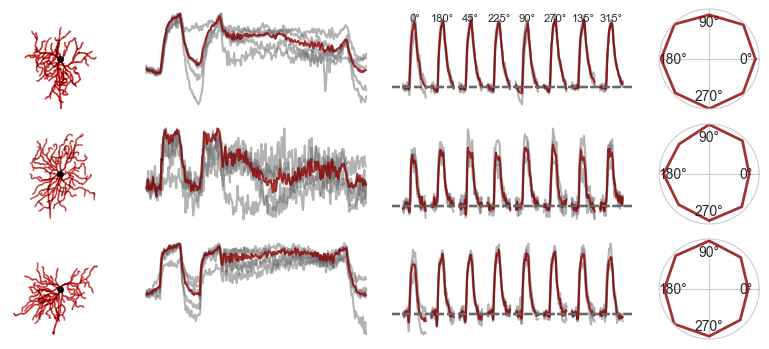

In [31]:
son_alpha_list = [720575940557469707, 720575940562911131, 720575940572157287, 720575940575066105]

df_type = df_merged[
    (df_merged[seg_col_master].astype(int).isin(son_alpha_list))
    & ((df_merged.chirp_qidx > 0.45) | (df_merged.bar_qidx > 0.6))
    & (df_merged["Status"] == 'Complete')
    ]

fig, axs = plot_cells(df_type.iloc[[0, 1, 3]])
plt.savefig(os.path.join(fig2_dir, 'examples_son_alphas.png'), dpi=600)

In [22]:
df_type

,Updated Nuc ID (Sept 2),Index,Nuc Coords,Soma Coords,Cell Type (deprecated),611 Proofreader,Proofreader 2,Status,AIS annotated?,Final Link,...,cluster_id,group_id,supergroup,prob_cluster,prob_group,prob_supergroup,prob_class,probs_per_cluster,seg_id,nuc_id
74,720575940557717614,D70,"37756.0,25423.0,481.0","37756.0,25423.0,551.0",NaN,Roden Rey,NaN,Complete,Annotated,https://spelunker.cave-explorer.org/#!middleau...,...,65,42,dAC,0.800745,0.813605,0.851197,0.851197,"[0.0018011936978988992, 0.0016883260287216724,...",720575940575066105,720575940557717614
111,720575940562660177,D108,"36503.0,14881.0,920.0","36503.0,14881.0,940.0",NaN,Baby Jane,NaN,Complete,Annotated,https://spelunker.cave-explorer.org/#!middleau...,...,60,38,dAC,0.649155,0.804270,0.908100,0.908100,"[0.0019573901079647806, 0.001844873759493815, ...",720575940562911131,720575940562660177
225,720575940562274734,D220,"30809.0,32035.0,216.0","30809.0,32035.0,256.0",NaN,Clerk,NaN,Complete,NaN,https://spelunker.cave-explorer.org/#!middleau...,...,65,42,dAC,0.780861,0.796684,0.921378,0.921378,"[0.001761923394869812, 0.0016181070283550736, ...",720575940557469707,720575940562274734
368,720575940562905653,D362,"52408.0,16643.0,1120.0","52204.0,16756.0,1153.0",NaN,Juliane,NaN,Complete,Annotated,https://spelunker.cave-explorer.org/#!middleau...,...,34,24,Slow ON,0.872015,0.872015,0.898019,0.955657,"[0.001785744907972071, 0.0017114739825568632, ...",720575940572157287,720575940562905653


[720575940563567973 720575940576092590 720575940581355463
 720575940563588453]


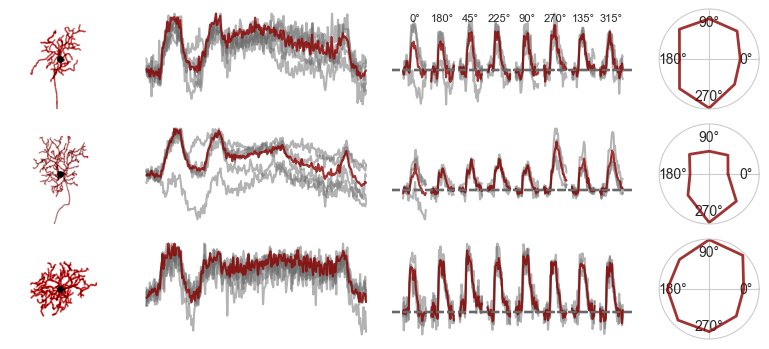

In [28]:
pixon_list = [720575940563567973, 720575940563588453, 720575940576092590, 720575940581355463]

df_type = df_merged[
    ((df_merged['Cell Type'] == 'PixON') | (
            (df_merged['Machine label'] == '9n') & (df_merged['Confidence machine label'].astype(float) > 0.5)))
    #(df_merged[seg_col_master].astype(int).isin(pixon_list))
    & ((df_merged.chirp_qidx > 0.45) | (df_merged.bar_qidx > 0.6))
    & (df_merged["Status"] == 'Complete')
    ]
df_type = df_type.drop_duplicates(subset=[seg_col_master], keep='first')

print(df_type[seg_col_master].values.astype(int))

fig, axs = plot_cells(df_type.iloc[[0, 1, 3]])
plt.savefig(os.path.join(fig2_dir, 'examples_pixon.png'), dpi=600)